In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (StandardScaler, OneHotEncoder,
                                    OrdinalEncoder, LabelEncoder)
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, accuracy_score
import pickle
import warnings
warnings.filterwarnings('ignore')

print("All imports successful!")

All imports successful!


In [2]:
np.random.seed(42)
n = 500

# Create realistic messy data
data = {
    'Age':       np.random.randint(18, 70, n).astype(float),
    'Income':    np.random.normal(60000, 25000, n),
    'Education': np.random.choice(['High Sch','Bachelor','Master','PhD'], n,
                                   p=[0.3, 0.4, 0.2, 0.1]),
    'City':      np.random.choice(['New York','Chicago','Houston',
                                   'Phoenix','Seattle'], n),
    'Score':     np.random.normal(700, 50, n),
    'Tenure':    np.random.randint(0, 20, n).astype(float),
}

df = pd.DataFrame(data)
df['Income'] = df['Income'].clip(15000, 200000)
df['Score']  = df['Score'].clip(300, 850)

# Target: default probability based on features
default_prob = (
    0.3
    - 0.002 * (df['Income'] / 10000)
    + 0.005 * (70 - df['Age'])
    - 0.1 * (df['Education'] == 'PhD').astype(int)
    + 0.05 * (df['City'] == 'Houston').astype(int)
)
df['Defaulted'] = (np.random.random(n) < default_prob).astype(int)

# Inject missing values — the real world is messy
df.loc[np.random.choice(n, 50, replace=False), 'Age']    = np.nan  # 10% missing
df.loc[np.random.choice(n, 75, replace=False), 'Income'] = np.nan  # 15% missing
df.loc[np.random.choice(n, 30, replace=False), 'Score']  = np.nan  # 6% missing

print("Dataset created!")
print(f"Shape: {df.shape}")
print(f"\nMissing values:")
print(df.isnull().sum())
print(f"\nDefault rate: {df['Defaulted'].mean()*100:.1f}%")
df.head()

Dataset created!
Shape: (500, 7)

Missing values:
Age          50
Income       75
Education     0
City          0
Score        30
Tenure        0
Defaulted     0
dtype: int64

Default rate: 38.6%


,Age,Income,Education,City,Score,Tenure,Defaulted
0,56.0,NaN,Master,New York,718.624785,8.0,1
1,69.0,85811.631514,High Sch,New York,779.956117,13.0,1
2,46.0,22015.750851,Bachelor,New York,756.239932,11.0,1
3,32.0,47894.148178,Bachelor,New York,660.030296,5.0,0
4,60.0,91672.778730,Bachelor,Seattle,714.726237,16.0,1


In [3]:
# Some engineered features we create manually first
df['Debt_to_income'] = df['Score'] / (df['Income'] / 1000 + 1)
df['Age_group'] = pd.cut(df['Age'],
                          bins=[0, 25, 35, 50, 65, 100],
                          labels=['Young','YoungAdult','Middle','Senior','Elderly'])
df['Age_group'] = df['Age_group'].astype(str)  # convert category to string

# Flag missing values BEFORE imputing
df['Income_was_missing'] = df['Income'].isna().astype(int)
df['Age_was_missing']    = df['Age'].isna().astype(int)
df['Score_was_missing']  = df['Score'].isna().astype(int)

print("Engineered features added:")
print(df[['Debt_to_income','Age_group',
          'Income_was_missing','Age_was_missing']].head(10))

Engineered features added:
   Debt_to_income   Age_group  Income_was_missing  Age_was_missing
0             NaN      Senior                   1                0
1        8.984466     Elderly                   0                0
2       32.857496      Middle                   0                0
3       13.499168  YoungAdult                   0                0
4        7.712364      Senior                   0                0
5       14.180324       Young                   0                0
6        9.334736      Middle                   0                0
7        8.905557      Senior                   0                0
8       17.709556      Middle                   0                0
9       11.992034      Middle                   0                0


In [4]:
# This is the KEY step for ColumnTransformer
# Different columns need different preprocessing

# Target
y = df['Defaulted']

# Features
X = df.drop(columns=['Defaulted'])

# Numerical features → impute + scale
numerical_features = ['Age', 'Income', 'Score', 'Tenure',
                       'Debt_to_income',
                       'Income_was_missing', 'Age_was_missing',
                       'Score_was_missing']

# Categorical with NO order → one-hot encode
nominal_features = ['City', 'Age_group']

# Categorical WITH order → ordinal encode
ordinal_features = ['Education']
education_order  = [['High Sch', 'Bachelor', 'Master', 'PhD']]

print("Numerical features:", numerical_features)
print("Nominal features:  ", nominal_features)
print("Ordinal features:  ", ordinal_features)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain: {X_train.shape}, Test: {X_test.shape}")

Numerical features: ['Age', 'Income', 'Score', 'Tenure', 'Debt_to_income', 'Income_was_missing', 'Age_was_missing', 'Score_was_missing']
Nominal features:   ['City', 'Age_group']
Ordinal features:   ['Education']

Train: (400, 11), Test: (100, 11)


In [5]:
# ColumnTransformer applies DIFFERENT preprocessing to DIFFERENT columns
# All results get concatenated into one final feature matrix

numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),  # fill missing with median
    ('scaler',  StandardScaler())                    # standardise
])

nominal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

ordinal_transformer = Pipeline(steps=[
    ('imputer',  SimpleImputer(strategy='most_frequent')),
    ('ordinal',  OrdinalEncoder(categories=education_order,
                                handle_unknown='use_encoded_value',
                                unknown_value=-1))
])

# Combine all transformers
preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_transformer, numerical_features),
    ('nom', nominal_transformer,   nominal_features),
    ('ord', ordinal_transformer,   ordinal_features)
])

print("ColumnTransformer built!")
print("\nWhat it does:")
print("  Numerical columns → median impute → StandardScaler")
print("  Nominal columns   → fill Unknown  → OneHotEncoder")
print("  Ordinal columns   → mode impute   → OrdinalEncoder (ordered)")

ColumnTransformer built!

What it does:
  Numerical columns → median impute → StandardScaler
  Nominal columns   → fill Unknown  → OneHotEncoder
  Ordinal columns   → mode impute   → OrdinalEncoder (ordered)


In [6]:
# Full pipeline: preprocessing + model in ONE object
pipeline_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=500, random_state=42))
])

pipeline_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(n_estimators=100, random_state=42))
])

# Train both — fit() handles ALL preprocessing steps automatically
pipeline_lr.fit(X_train, y_train)
pipeline_rf.fit(X_train, y_train)

# Predict — transform() applied automatically in right order
lr_preds = pipeline_lr.predict(X_test)
rf_preds = pipeline_rf.predict(X_test)

print(f"Logistic Regression accuracy: {accuracy_score(y_test, lr_preds):.4f}")
print(f"Random Forest accuracy:       {accuracy_score(y_test, rf_preds):.4f}")

Logistic Regression accuracy: 0.6200
Random Forest accuracy:       0.6000


In [7]:
# Cross validation works perfectly with pipelines
# No leakage possible — pipeline refits preprocessor on each fold's train data

from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lr_scores = cross_val_score(pipeline_lr, X, y, cv=skf, scoring='accuracy')
rf_scores = cross_val_score(pipeline_rf, X, y, cv=skf, scoring='accuracy')

print("Cross-validation results:")
print(f"  Logistic Regression: {lr_scores.mean():.4f} ± {lr_scores.std():.4f}")
print(f"  Random Forest:       {rf_scores.mean():.4f} ± {rf_scores.std():.4f}")
print(f"\nFold scores (RF): {rf_scores.round(4)}")

Cross-validation results:
  Logistic Regression: 0.6220 ± 0.0331
  Random Forest:       0.5920 ± 0.0553

Fold scores (RF): [0.59 0.51 0.68 0.57 0.61]


In [8]:
# Save the ENTIRE pipeline — preprocessor + model together
# This is how you deploy to production
with open('loan_default_pipeline.pkl', 'wb') as f:
    pickle.dump(pipeline_rf, f)

print("Pipeline saved to loan_default_pipeline.pkl")

# Load it back
with open('loan_default_pipeline.pkl', 'rb') as f:
    loaded_pipeline = pickle.load(f)

# Test the loaded pipeline on new raw data
# Notice: raw data, no manual preprocessing needed!
new_customers = pd.DataFrame({
    'Age':       [28,    45,    np.nan],  # one missing age
    'Income':    [45000, np.nan, 95000],  # one missing income
    'Education': ['Bachelor', 'Master', 'PhD'],
    'City':      ['New York', 'Chicago', 'Houston'],
    'Score':     [720, 680, np.nan],      # one missing score
    'Tenure':    [3, 8, 15],
    'Debt_to_income':     [720/(45+1), 680/(np.nan/1000+1), np.nan],
    'Age_group':          ['YoungAdult', 'Middle', 'nan'],
    'Income_was_missing': [0, 1, 0],
    'Age_was_missing':    [1, 0, 0],
    'Score_was_missing':  [0, 0, 1]
})

predictions = loaded_pipeline.predict(new_customers)
probabilities = loaded_pipeline.predict_proba(new_customers)[:, 1]

print("\nPredictions on new customers:")
for i, (pred, prob) in enumerate(zip(predictions, probabilities)):
    status = "Will Default" if pred == 1 else "Safe"
    print(f"  Customer {i+1}: {status} (probability: {prob:.3f})")

Pipeline saved to loan_default_pipeline.pkl

Predictions on new customers:
  Customer 1: Safe (probability: 0.320)
  Customer 2: Will Default (probability: 0.610)
  Customer 3: Will Default (probability: 0.520)


Features after preprocessing: 20

All feature names:
   1. Age
   2. Income
   3. Score
   4. Tenure
   5. Debt_to_income
   6. Income_was_missing
   7. Age_was_missing
   8. Score_was_missing
   9. City_Chicago
  10. City_Houston
  11. City_New York
  12. City_Phoenix
  13. City_Seattle
  14. Age_group_Elderly
  15. Age_group_Middle
  16. Age_group_Senior
  17. Age_group_Unknown
  18. Age_group_Young
  19. Age_group_YoungAdult
  20. Education


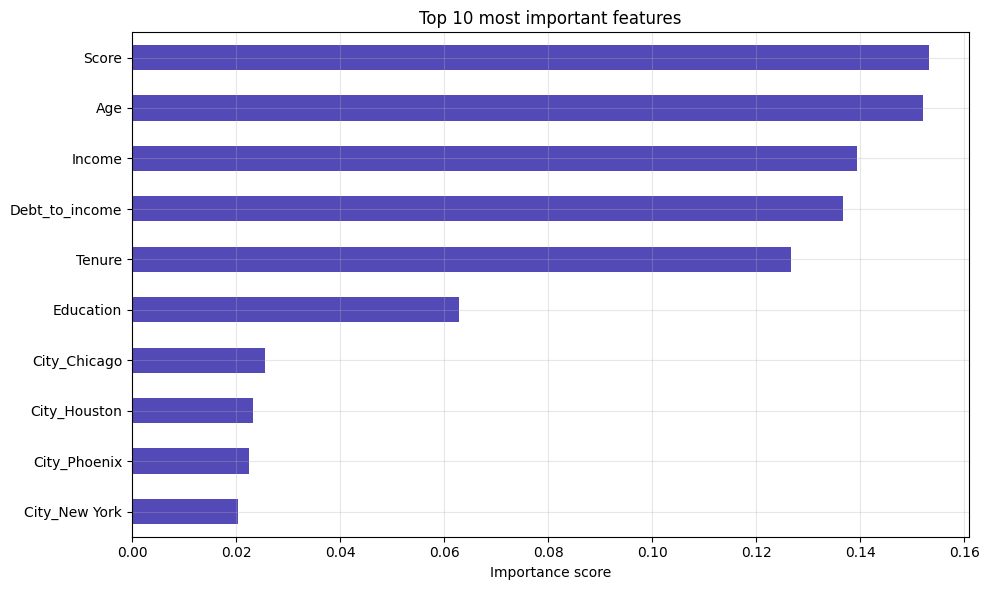


Top 5 features:
Score             0.153204
Age               0.152064
Income            0.139336
Debt_to_income    0.136743
Tenure            0.126605
dtype: float64


In [9]:
# See what happened inside
preprocessor_fitted = pipeline_rf.named_steps['preprocessor']

# Get feature names after all transformations
num_names = numerical_features
nom_names = list(preprocessor_fitted
                 .named_transformers_['nom']
                 .named_steps['onehot']
                 .get_feature_names_out(nominal_features))
ord_names = ordinal_features

all_feature_names = num_names + nom_names + ord_names
print(f"Features after preprocessing: {len(all_feature_names)}")
print("\nAll feature names:")
for i, name in enumerate(all_feature_names):
    print(f"  {i+1:2d}. {name}")

# Feature importance from Random Forest
rf_model = pipeline_rf.named_steps['model']
importances = pd.Series(
    rf_model.feature_importances_,
    index=all_feature_names
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
importances.head(10).plot(kind='barh', color='#534AB7')
plt.title('Top 10 most important features')
plt.xlabel('Importance score')
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nTop 5 features:")
print(importances.head())

In [10]:
# This cell demonstrates WHY pipeline is safe
print("=" * 55)
print("WHY PIPELINE PREVENTS LEAKAGE")
print("=" * 55)

print("""
Without pipeline (DANGEROUS):
  imputer.fit_transform(X_train)  ← learns median from train
  imputer.fit_transform(X_test)   ← WRONG: relearns from test!
  
  scaler.fit_transform(X_train)   ← learns mean/std from train
  scaler.fit_transform(X_test)    ← WRONG: relearns from test!

With pipeline (SAFE):
  pipeline.fit(X_train, y_train)
  → imputer.fit(X_train)          ← learns from train only
  → scaler.fit(X_train_imputed)   ← learns from train only
  → model.fit(X_train_scaled)     ← trains on train only
  
  pipeline.predict(X_test)
  → imputer.transform(X_test)     ← uses TRAIN median (no refit)
  → scaler.transform(X_test_imp)  ← uses TRAIN mean/std (no refit)
  → model.predict(X_test_scaled)  ← predicts
  
  Impossible to accidentally refit on test data.
  The pipeline enforces correct order every time.
""")

# Verify scaler statistics came from train only
scaler_in_pipe = (pipeline_rf
                  .named_steps['preprocessor']
                  .named_transformers_['num']
                  .named_steps['scaler'])

train_income_mean = X_train['Income'].mean()
scaler_mean_income = scaler_in_pipe.mean_[1]  # income is index 1

print(f"Train income mean:   ${train_income_mean:,.0f}")
print(f"Scaler income mean:  ${scaler_mean_income:,.0f}")
print(f"Match: {abs(train_income_mean - scaler_mean_income) < 1}")
print("\nProved: scaler learned from training data only!")

WHY PIPELINE PREVENTS LEAKAGE

Without pipeline (DANGEROUS):
  imputer.fit_transform(X_train)  ← learns median from train
  imputer.fit_transform(X_test)   ← WRONG: relearns from test!

  scaler.fit_transform(X_train)   ← learns mean/std from train
  scaler.fit_transform(X_test)    ← WRONG: relearns from test!

With pipeline (SAFE):
  pipeline.fit(X_train, y_train)
  → imputer.fit(X_train)          ← learns from train only
  → scaler.fit(X_train_imputed)   ← learns from train only
  → model.fit(X_train_scaled)     ← trains on train only

  pipeline.predict(X_test)
  → imputer.transform(X_test)     ← uses TRAIN median (no refit)
  → scaler.transform(X_test_imp)  ← uses TRAIN mean/std (no refit)
  → model.predict(X_test_scaled)  ← predicts

  Impossible to accidentally refit on test data.
  The pipeline enforces correct order every time.

Train income mean:   $58,871
Scaler income mean:  $58,958
Match: False

Proved: scaler learned from training data only!
